In [1]:
JSON_FILE_PATH = "./json/side/A1-A3.json"

In [2]:
from src.json_to_pose.base import Pose, PoseAnalyzer, blazepose_lines
from src.utils.process_data import translate_multi_kpt_to_plot_pos
import src.utils.plot_painter as plot_painter

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# 參考類型
from mpl_toolkits.mplot3d import Axes3D

In [3]:
pose = Pose(JSON_FILE_PATH)
analyzer = PoseAnalyzer(pose)
json_path = Path(JSON_FILE_PATH)

In [4]:
### 視角參數

### 預設
# elev, azim, roll = 20, 30, 0

## 正面影像
# elev, azim, roll = 30, 90, 0  # 正面
# elev, azim, roll = 30, 180, 0  # 右側

## 右側影像
# elev, azim, roll = 30, 0, 0  # 正面
# elev, azim, roll = 30, 270, 0  # 右側

In [5]:
### 參數設定

# 設定視角
elev, azim, roll = 30, 270, 0  # 正面

# 顯示資料範圍
data_range_x = [-1, 1]  # x 軸
data_range_y = [-1, 1]  # y 軸
data_range_z = [0, 2]  # z 軸

# 圖表資訊顏色
c_left = "#f00"  # 左邊
c_center = "#0f0"  # 右邊
c_right = "#00f"  # 中間
c_dot = "#000"  # 關鍵點

idx_img = 0  # 圖片索引值
get_3d = True  # 是否為 3D 姿勢
dot_size = 5  # 繪製關鍵點大小
line_lst = blazepose_lines  # 設定連線列表

In [6]:
# 判斷圖片是否有姿勢
assert pose.get_pose_count(idx_img) > 0

# 取得資料
p_left, p_center, p_right = analyzer.get_pose_line_postions(idx_img, 0, line_lst, get_3d)
p_kpt = pose.get_pose_kpt_positions(idx_img, 0, get_3d)
label = analyzer.get_pose_lhc_label(idx_img, 0, get_3d)
score = pose.get_pose_score(idx_img, 0)

In [7]:
### 對座標進行轉換
p_kpt, p_left, p_center, p_right = translate_multi_kpt_to_plot_pos(
    p_kpt, p_kpt, p_left, p_center, p_right
)

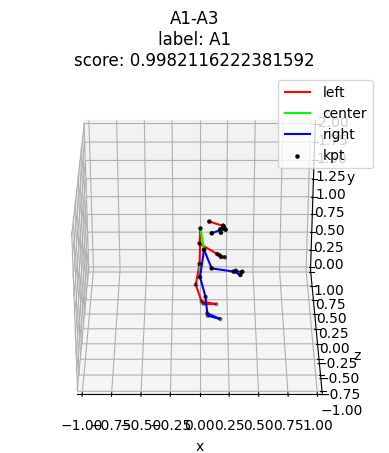

In [8]:
### 繪製表格
if not get_3d:
    ax = plt.subplot()
else:
    ax: Axes3D = plt.subplot(projection="3d")  # 建立表格
    ax.view_init(elev, azim, roll)  # 設置視角

# 圖表設定
ax.set_title(f"{json_path.stem}\nlabel: {label}\nscore: {score}")  # 設定標題
plot_painter.set_data_range(data_range_x, data_range_y, data_range_z, ax)

plot_painter.draw_lines(p_left, get_3d, c_left, "left", ax)
plot_painter.draw_lines(p_center, get_3d, c_center, "center", ax)
plot_painter.draw_lines(p_right, get_3d, c_right, "right", ax)
plot_painter.draw_dots(p_kpt, get_3d, dot_size, c_dot, "kpt", ax)

ax.legend()
plt.show()